# SVM BINARY CLASSIFIER FROM SCRATCH WITH JAX
SVMs are a supervised machine learning algorithms used for classification and regression tasks. They work by finding the optimal hyperplane that separates data points of different classes with the maximum margin.

As sci-kit learn is converting our jax.numpy inputs to numpy, we will implement a SVM model optimized for Jax from scratch.
# ___________________________________________


# SETUP 

In [ ]:
import sys
print(sys.executable)
print(sys.path)
import jax
import jax.numpy as np
sys.path.insert(0,"2526_INFOB318_Kernax/project/SVM")
from jax import jit
from functools import partial
from Kernax import LinearKernel, SEMagmaKernel
import optax

# VARIABLES INITIALIZATION 
 So we are initializing the variables of our SVM here, based on the SVM primal problem known equation Wx + b =y. and dual problem one.

 A parameter for the kernel used is also considered with an instance for the testing points(it is useful for the predict part)

  alpha is basically the equivalent to w but it's useful for rbf etc where the data is non linearly separable and we need to implicitly map to an infinite higher dimensional space.

  kernel fn is the parameter that corresponds to the covariance matrix


In [ ]:
class SVM:

    def __init__(self, C = 1.0):
        # C = error term
        self.C = C
        self.w = 0
        self.b = 0
        self.kernel = None
        self.X_train = None  
        self.y_train = None  
        self.alpha = None
        self.kernel_fn = None  

# Hinge loss functions
 The hinge loss function is useful for obtaining the best w and b parameters (which will be used to DEFINE our hyperplane) in the gradient descent algorithm, this function could be effectively be jitted as there is no control flow that depends on the static attributes of the inputs 

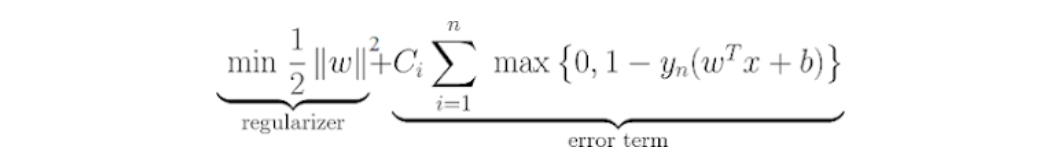
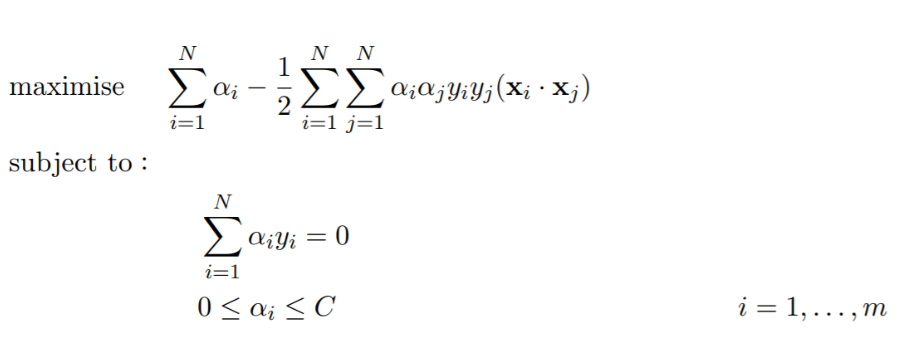

In [ ]:
@partial(jit, static_argnums=(0,))
def hingeloss(self, w, b, x, y):
    # Regularizer term
     reg = 0.5 * np.sum(w * w)  
    
    
    # We calculate all the scores in one time, so we don't use a for loop
     scores = np.dot(x, w) + b
     
    # hinge loss for all elements of our sample
     hinge_losses = np.maximum(0, 1 - y * scores)
    
    # mean of all elements of our sample
     avg_hinge = np.mean(hinge_losses)
    
    # total loss
     total_loss = reg + self.C * avg_hinge
    
     return total_loss


# Fit function
So basicaly, the fit function is the most important function in SVMs, it will find us the best w and b hyperparameters that will be used to define our hyperplane, basically, it will run a gradient descent algorithm on a matrix(that matrix could be a cov matrix) and labels. For the moment, only rbf and the basic linear kernel are considered.


# Fit function implementation
 


In [ ]:
def fit(self, X, Y, batch_size=100, learning_rate=0.001, epochs=1000):
        # The number of features in X
        self.X_train = X.copy()

        X = np.array(X, dtype=np.float32)
        Y = np.array(Y, dtype=np.float32)
        assert X.ndim == 2, "X should be in two dimensions"
        assert Y.ndim == 1, "Y should be in one dimension"
        assert len(X) == len(Y), "X and Y should have the same length"
    
        #As the dual problem and primal don't have have the same parameters, i need to optimize in two different ways
        if(self.kernel == "squarexpo"):
            X = SEMagmaKernel(length_scale = 2.0,variance=1.0)(X,X)
            print(X)
            print(type(X))
            self.kernel_fn = SEMagmaKernel(length_scale=2.0, variance=1.0)
            K = self.kernel_fn(X, X) 
            # We initialize alphas (so basically that's the dual coefficients)
            n_samples = X.shape[0]
            alpha = np.zeros(n_samples)

            # We want to optimize our alphas

            optimizer = optax.adam(learning_rate=learning_rate)
            opt_state = optimizer.init(alpha)
            losses = []
            for i in range(epochs):
                loss, grad_alpha = jax.value_and_grad(self.dual_loss)(alpha, X, Y, K)
                # Updates of the alpha values, so basically it's the same logic as the primal problem 

                updates, opt_state = optimizer.update(grad_alpha, opt_state, alpha)
                alpha = optax.apply_updates(alpha, updates)
                # So this the contraint of our dual problem which states that alphas should be between 0 and c
                alpha = np.clip(alpha, 0, self.C)
                losses.append(loss)

            self.alpha = alpha    
            # When we are in the dual problem there's no weight
            self.w = None

            sv_indices = np.where(alpha > 1e-5)[0]  # support vectors
            if len(sv_indices) > 0:
                # for each support vector we need to calculate the bias
                b_vals = []
                for idx in sv_indices:
                    prediction = np.sum(alpha[sv_indices] * Y[sv_indices] * K[sv_indices, idx])
                    b_vals.append(Y[idx] - prediction)
                self.b = np.mean(np.array(b_vals))
            else:
                self.b = 0
            
            return self.alpha, self.b, losses

        number_of_features = X.shape[1]

        # The number of Samples in X
        number_of_samples = X.shape[0]

        c = self.C

        # Creating ids from 0 to number_of_samples - 1
        ids = np.arange(number_of_samples)
        key = jax.random.key(0)
        # Shuffling the samples randomly
        jax.random.permutation(key,ids)

        # creating an array of zeros
        w = np.zeros(number_of_features) 
        b = 0.0
        losses = []


        # The paramaters that we're going to use for optax
        params = {'w': w, 'b': b}
        # The optimizer that we will use to update our w and b and find the best ones.
        optimizer = optax.adam(learning_rate=learning_rate)

        opt_state = optimizer.init(params)

        for i in range(epochs):
            # Calculating the Hinge Loss
            loss, (grad_w, grad_b) = jax.value_and_grad(self.hingeloss, (0, 1))(params["w"], params["b"], X, Y)
            grads = {'w': grad_w, 'b': grad_b}
 
           
            losses.append(loss)
            # Basically, updates are what we will add to our old w and b, donc les grads
            updates, opt_state = optimizer.update(grads, opt_state, params)
            # We apply the updates on our parameters (so basically we update our weight and bias based on their values and grads)
            params = optax.apply_updates(params, updates)
        self.w = params["w"]
        self.b = params["b"]
        return params["w"], params["b"], losses
            

# Predict function
Our predict function is classic, for both the dual and primal problem we will simply calculate the label of a given test point based on the output of a decision function

In [ ]:
 @partial(jit, static_argnums=(0,))
 def predict(self, X):
        if(self.kernel == 'squarexpo'):
            assert self.alpha is not None, "if there is no alphas then the model wasn't trained "
            assert self.X_train is not None, "no data points"
            
            # Kernel matrix between X and the training points
            K_test = self.kernel_fn(X, self.X_train)
            
            # decision function of dual problems
            decisions = np.dot(K_test, self.alpha * self.y_train) + self.b
            return np.sign(decisions)

            

        prediction = np.dot(X, self.w) + self.b
        return np.sign(prediction)

# Gradient adam algorithm jit possibilites and details.
The Adam optimizer.

Adam is an SGD variant with gradient scaling adaptation. The scaling used for each parameter is computed from estimates of first and second-order moments of the gradients (using suitable exponential moving averages).

So basically here for the primal problem,
The optimizer will calculate the updates(the gradients for our weight and bias) and add them to the old values of w and b, to compute the new ones.

For the dual problem it will be the same logic but applied to alpha.



# Square expo
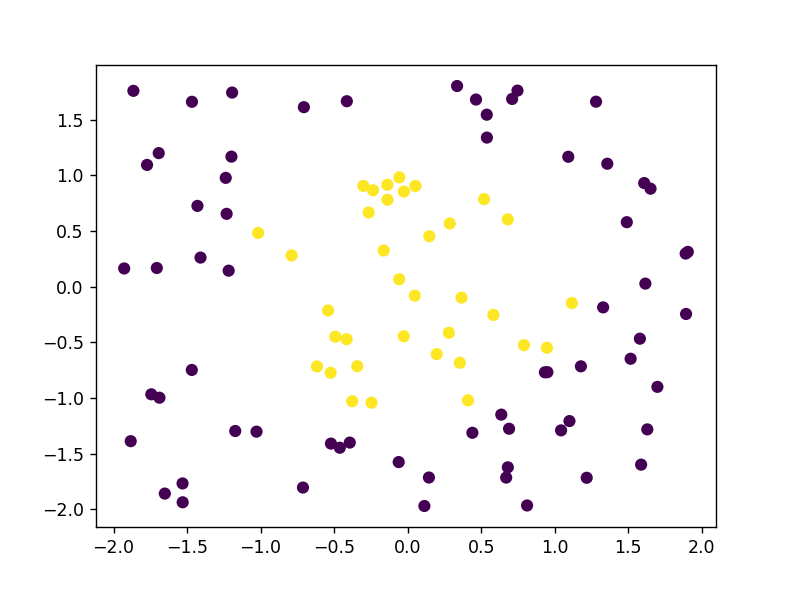
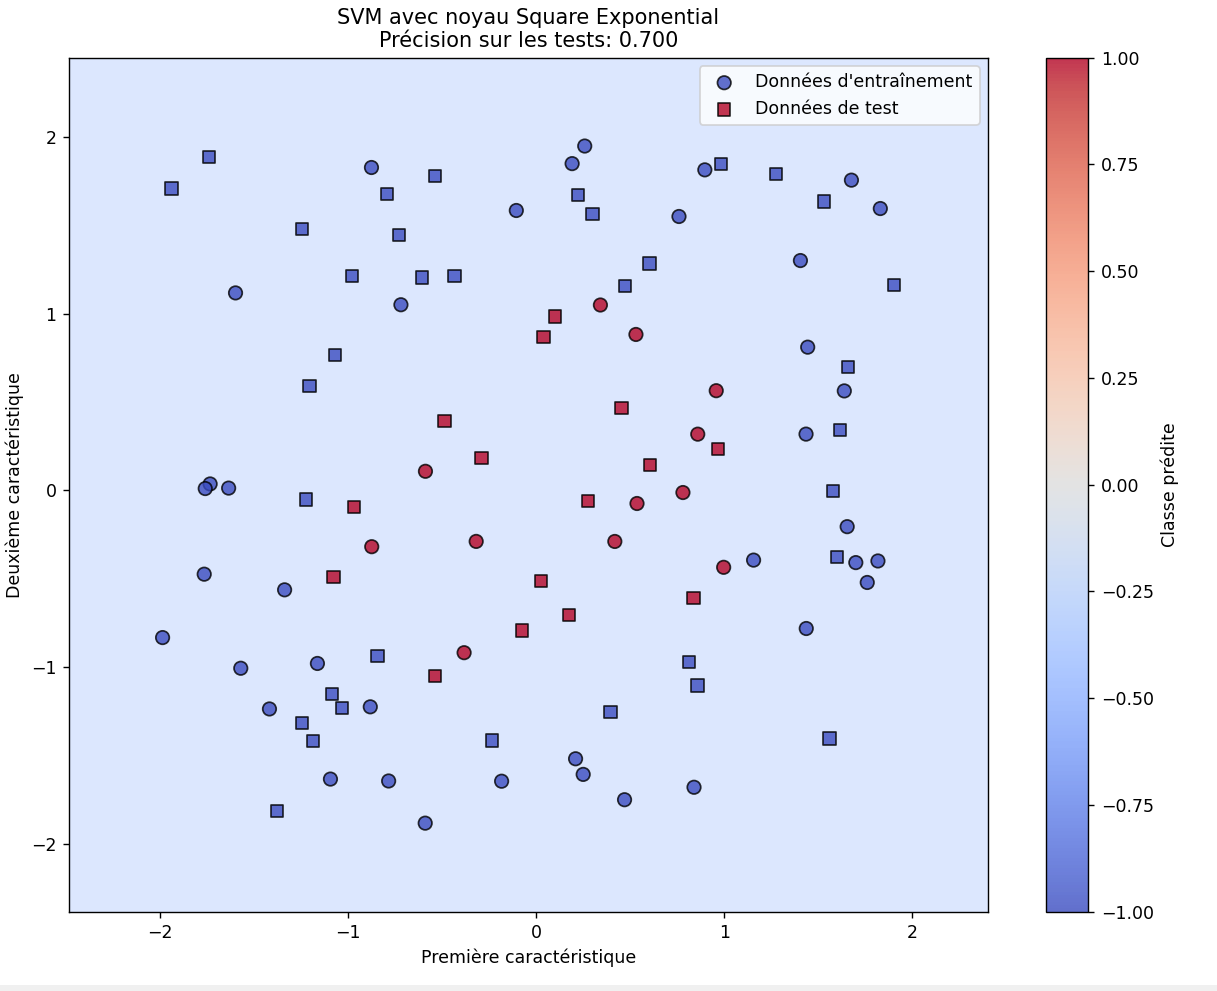